# Wildfire Prediction

## Table of content

- Read data

- Exploratory data analysis
    - Data structure
    - Class balance
    - FWI distribution
    - Fire Class by time period

- ML Model Training
    - Load train/validate/test split
    - Set up Models
        - Random Forest
        - Logistic Regression
    - Hyperparameter Tunning (Training set)
        -  Randomized Search + TimeSeriesSplit
    - Validate Hyperparameter tuning (Validation set)
        - F1 Score
        - Recall
        - AUC
        - Classification Report
    - Repeat Hyperparameter and Validation (...if required)
        - Refine hyperparameters
    - Testing (Test set)
        - F1 Score
        - Recall
        - AUC
        - Classification Report
- Outputs
    - Generates the various images, tables, and outputs required for writeup 

## Read data

### Libraries

In [ ]:
import utils.datasets_utils as du
import ml_models.ml_utils as mu
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os 
import time
from scripts.s00_set_parameters import PARAMETERS
from typing import Any
from joblib import dump, load

### Load data

In [2]:
# Base path/location of data
path_base = PARAMETERS['DATA_DIR']/"MLInputs"
# Input files to load
files_to_load = {"resnet_default_weights":  "2026-07-12_ml_input.csv",
                 "resnet_layer4_finetuned": "2026-07-19_ml_input_layer4_finetuned.csv"}
# Generate full paths 
files_to_load = {k: os.path.join(path_base, v) for (k, v) in files_to_load.items()}
# Spefic data types requirements
string_cols = {"composite_key": "string", "composite_key_y": "string", "bridge_composite_key_y": "string"}
date_cols   = ["date_y", "date"]
# Load data 
df_resnet_default   = pd.read_csv(files_to_load["resnet_default_weights"], dtype  = string_cols, parse_dates=date_cols) #type: ignore
df_resnet_finetuned = pd.read_csv(files_to_load["resnet_layer4_finetuned"], dtype = string_cols, parse_dates=date_cols) #type: ignore


## Exploratory data analysis

### Data structure

Ensure that the structure of both data frames is the same. The only difference should be the values in the feature columns - everything else should be equal

In [3]:
# Validate structure is the same
print("Structure Validation: ")
print(f"- Columns match:    {df_resnet_finetuned.columns.equals(df_resnet_default.columns)}")
print(f"- Data types match: {df_resnet_finetuned.dtypes.equals(df_resnet_default.dtypes)}")
print(f"- Data Shape match: {df_resnet_finetuned.shape == df_resnet_default.shape}")

# Validate that the only data differences are found in feature columns, all other data points should be the same between data frames 
feat_cols               = [c for c in df_resnet_default.columns if re.search("^feat_", c)]
df_minus_feat_default   = df_resnet_default.drop(columns=feat_cols)
df_minus_feat_finetuned = df_resnet_finetuned.drop(columns=feat_cols)
# Validate data matches
print("\nData Validation:")
try:
    pd.testing.assert_frame_equal(df_minus_feat_default,  df_minus_feat_finetuned)
    print("- Non-feature data match: True")
except AssertionError as e:
    print("- Non-feature data match: False")
    print(e)

Structure Validation: 
- Columns match:    True
- Data types match: True
- Data Shape match: True

Data Validation:
- Non-feature data match: True


Columns and data types for reference:

In [80]:
col_names = df_resnet_default.columns
for pos, dt in enumerate(df_resnet_default.dtypes):
    print(f"{col_names[pos]}: \t\t\t{dt}")
  

composite_key_y: 			string
grid_id_y: 			int64
sample_type_y: 			str
date_y: 			datetime64[us]
fire_lbl_y: 			bool
bridge_composite_key_y: 			string
grid_id: 			float64
x_coord: 			float64
y_coord: 			float64
geometry: 			str
date: 			datetime64[us]
viirs_n: 			float64
frp_max: 			float64
frp_mean: 			float64
fire_lbl: 			bool
fwi_max: 			float64
fwi_mean: 			float64
composite_key: 			string
feat_000: 			float64
feat_001: 			float64
feat_002: 			float64
feat_003: 			float64
feat_004: 			float64
feat_005: 			float64
feat_006: 			float64
feat_007: 			float64
feat_008: 			float64
feat_009: 			float64
feat_010: 			float64
feat_011: 			float64
feat_012: 			float64
feat_013: 			float64
feat_014: 			float64
feat_015: 			float64
feat_016: 			float64
feat_017: 			float64
feat_018: 			float64
feat_019: 			float64
feat_020: 			float64
feat_021: 			float64
feat_022: 			float64
feat_023: 			float64
feat_024: 			float64
feat_025: 			float64
feat_026: 			float64
feat_027: 			float64
feat_028: 			floa

The full dataset contains the columns below. All the columns that end with suffix `y` refer to be values to be predicted. These are the values that the model needs to predict. The rest of the columns contain the data to train the model. The training data (non `y` columns) are from a t-1 from value to predict. 

In [81]:
# Check assumptions for all datasets
for _, row in df_resnet_default.iterrows():
    row: Any
    days_diff = (row.date_y - row.date).days
    if days_diff != 1:
        print('❌ Date assumption of t-1 not met!')
print(f"✅ t-1 assumption validated\n  [{df_resnet_default.shape[0]} rows checked]")

✅ t-1 assumption validated
  [38204 rows checked]


### Class balance

The sampling procedure implemented a 2:1 no-fire to fire ratio when selecting the samples. The reason of this is that no-fire events are much more common than fire events. However, using the real distribution would have produced an extremely imbalanced dataset. To mitigate this, a 2:1 ratio was implemented to maintain the frequency property but reducing the class imbalance to a more manageable state, as done by previous studies. 

The complete details of the sampling procedure are in:
- Functions: `src/sampling/sampling_functions.py` 
- Pipeline: `src/pipelines/sampling_pipeline.py`

In [82]:
print("=== Class Balance ===")
print(df_resnet_default['fire_lbl_y'].value_counts(normalize=True))



=== Class Balance ===
fire_lbl_y
False    0.614412
True     0.385588
Name: proportion, dtype: float64


### FWI Distribution

#### Tabular

The class imbalance in the predictor variable is evident, with only 1,816 fire observations vs 36,388 no-fire observations (see `df_fwi_descriptives` below).

The descriptive statistics show that the fire class, overall, has higher FWI values than the no fire, with the median of fire observations (*M = 2.55*) almost 3 times higher than the no-fire (*M = 0.91*) counterpart. It is worth nothing, however, that the max value of no-fire is greater than the fire (more than 2sd above the max). This is the case for 7/36388 of the no-fire observations, which indicates these are rare observations (See FWI - BLOCK 2).

In [83]:
# FWI - BLOCK 1 - Descriptives
df_fwi_descriptives = df_resnet_default[['fwi_mean', 'fire_lbl']].groupby('fire_lbl').describe()
df_fwi_descriptives

fwi_mean                                                        \
            count      mean       std           min       25%       50%   
fire_lbl                                                                  
False     36388.0  3.620400  5.880850  1.721512e-09  0.257813  0.914331   
True       1816.0  5.732212  7.466659  1.724128e-09  0.690369  2.551709   

                               
               75%        max  
fire_lbl                       
False     4.617249  68.532227  
True      7.889746  50.774902

In [84]:
# FWI - BLOCK 2 - FWI value max review
# Count of no fire observations above the max of Fire
fwi_fire_lbl_max = df_fwi_descriptives.loc[True, ("fwi_mean", "max")]
df_resnet_default[ (df_resnet_default['fire_lbl'] == False) & (df_resnet_default['fwi_mean'] > fwi_fire_lbl_max)].shape[0]

7

#### Visualisation

To visually compare the distribution of FWI values between fire and no-fire observations a histogram of raw counts is not appropiate given the large class imbalance. The dataset contains many more no-fire than fire observations, therefore, the no-fire class dominates the the histogram, making it difficult to compare the two classes

Text(0.5, 1.0, 'Distribution of Fire Weather Index')

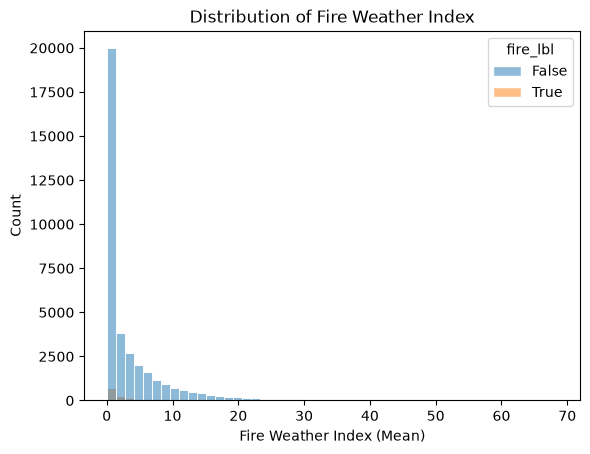

In [85]:
sns.histplot(data=df_resnet_default,
             x="fwi_mean",
             hue = 'fire_lbl',
             bins = 50,
             edgecolor = "white")
plt.xlabel("Fire Weather Index (Mean)")
plt.ylabel("Count")
plt.title("Distribution of Fire Weather Index")

Instead, comparing the **distribution** of each class provides a more informative visualisation of the FWI data. By normalising each class independently, the underlying distributions can be compared without being obscured by the class imbalance, making the class differences easier to observe.

The `common_norm` parameter is set to `False` to ensure that each class is normalised independently. By default, the histogram is normalised across both classes, meaning that the combined area under the two distributions would sum to 1, which makes visual comparisons hard to communicate as the majority class would overtake the visual space. Instead, with `common_norm` set to `False` the function normalises each class separately, so the area under each class distribution sums to 1. This allows to visually compare the fire and no-fire observations distributions independently of class imbalance. 


<Axes: xlabel='fwi_mean', ylabel='Density'>

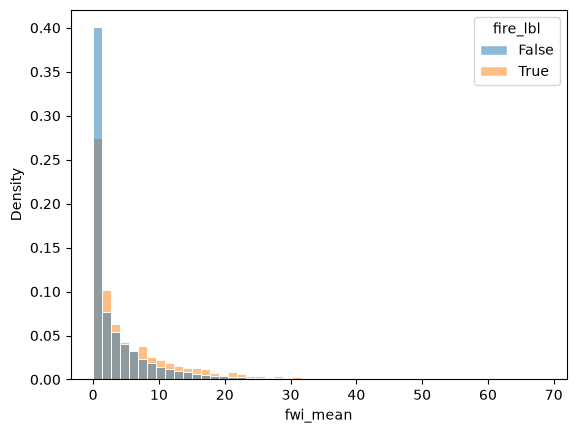

In [86]:
sns.histplot(data = df_resnet_default,
             x = "fwi_mean",
             hue = "fire_lbl",
             bins = 50,
             stat = "density",
             common_norm = False,
             edgecolor = "white")

#### Data by Class over time period

In [87]:
# Helper function to create stacked bar chart to show split by temporal bins and fire, no-fire observations
def summarise_obs_by_time(df_in:pd.DataFrame, temporal_split = 'year') -> dict:
    barchart_data = {}
    for row in df_in.itertuples():
        row: Any
        temporal_string = du.get_temporal_label(row.date, temporal_split)
        fire_lbl        = row.fire_lbl

        if temporal_string not in barchart_data:
            barchart_data[temporal_string] = {"fire": 0, "no_fire": 0}

        if fire_lbl:
            barchart_data[temporal_string]["fire"] += 1
        else:
            barchart_data[temporal_string]["no_fire"] += 1
    return barchart_data


Review how many observations per year

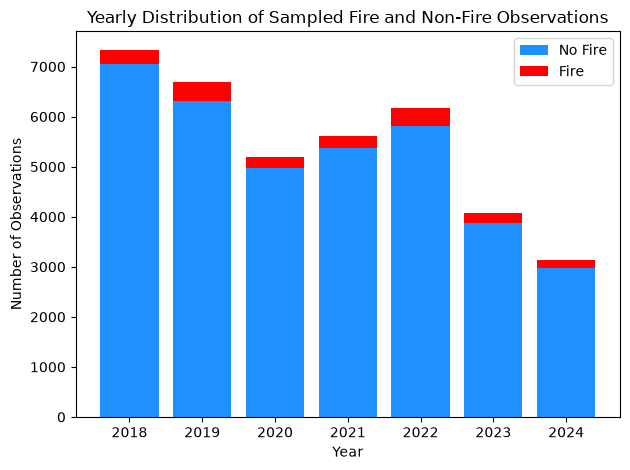

In [88]:
df_plot = pd.DataFrame(summarise_obs_by_time(df_resnet_default, 'year'))
plt.bar(df_plot.columns,
        df_plot.loc['no_fire'],
        color = 'dodgerblue',
        label="No Fire")

plt.bar(df_plot.columns,
        df_plot.loc['fire'],
        bottom = df_plot.loc['no_fire'],
        color = 'red',
        label="Fire")


plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.title("Yearly Distribution of Sampled Fire and Non-Fire Observations")

plt.legend()
plt.tight_layout()
plt.show()

## ML Model Training

### Load Train/Test split

In [4]:
# =============
# SPLIT DATA
# =============
# reserve the test data, do not use in crossvalidation process
df_train, df_test       = mu.train_test_temporal_split(df_resnet_default)
df_train_ft, df_test_ft = mu.train_test_temporal_split(df_resnet_finetuned)

# REMINDER - All feature column names are already saved in:
feat_cols = feat_cols

# Validate that the temporal split for both datasets is the same apart from Sentinel-2 data
# This allows for a single set of y values to be used instead of duplicating work
validation_pairs = [("Training", df_train, df_train_ft),
                    ("Test", df_test, df_test_ft)]

for name, df_a, df_b in validation_pairs:
    print(f"\n{name} data validation:")
    try:
        pd.testing.assert_frame_equal(df_a.drop(columns=feat_cols), df_b.drop(columns=feat_cols))
        print("- Non-feature data match: True")

    except AssertionError as e:
        print("- Non-feature data match: False")
        print(e)



ℹ️  INFO Train/Test split based on date
Requested train size : 0.7000
Actual train size    : 0.7037
Actual test size     : 0.2963

ℹ️  INFO Train/Test split based on date
Requested train size : 0.7000
Actual train size    : 0.7037
Actual test size     : 0.2963

Training data validation:
- Non-feature data match: True

Test data validation:
- Non-feature data match: True


In [ ]:
# Hybrid Model columns
hybrid_cols = feat_cols + ['fwi_mean']
# =============
# Y VALUES
# =============
# Split Y labels by default and training to ensure correctness and consitency
y_train = df_train["fire_lbl_y"]
y_test  = df_test["fire_lbl_y"]

# =============
# X VALUES
# =============
# FWI can be taken from default or fine tuned, no difference in data as shown in code blocks above
X_train_fwi = df_train.loc[:, ["fwi_mean"]]
X_test_fwi  = df_test.loc[:,  ["fwi_mean"]]

# Sentinel-2 Default ResNet18 Weights
X_train_sent2_def = df_train.loc[:, feat_cols]
X_test_sent2_def  = df_test.loc[:, feat_cols]
# Hybrid, Sentinel-2 Default ResNet18 Weights
X_train_hybrid_def = df_train.loc[:, hybrid_cols]
X_test_hybrid_def  = df_test.loc[:, hybrid_cols]

# Sentinel-2 fineTuned ResNet18 Weights
X_train_sent2_ft = df_train_ft.loc[:, feat_cols]
X_test_sent2_ft  = df_test_ft.loc[:, feat_cols]
# Hybrid, Sentinel-2 fineTuned ResNet18 Weights
X_train_hybrid_ft = df_train_ft.loc[:, hybrid_cols]
X_test_hybrid_ft  = df_test_ft.loc[:, hybrid_cols]

# Combine predictor data into a single dictionary
training_predictor_data = {'fwi': X_train_fwi,
                           
                           'sentinel_default': X_train_sent2_def,
                           'hybrid_default'  : X_train_hybrid_def,

                           'sentinel_fineTuned': X_train_sent2_ft,
                           'hybrid_fineTuned'  : X_train_hybrid_ft}

### Initialise Models

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve

random_state = 42
class_weight = 'balanced'

# Initialise models
models = {'random_forest': RandomForestClassifier(random_state=random_state,n_jobs =-1),
          'logistic_reg':  Pipeline([("scaler", StandardScaler()),
                                        ("lr", LogisticRegression(random_state=random_state,
                                                                  max_iter = 1000))])
}


### Hyperparameter Tuning

In [7]:
# Hyperparameters
params = {'random_forest': {
    'criterion': ['gini', 'entropy'], 
    'n_estimators': [100, 250, 500],  # Number of trees
    'max_features': ['log2', 'sqrt', 0.3,0.5],  # Number of features to consider for best split
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]},  # Minimum samples required at each leaf node
 

        'logistic_reg': {'lr__solver': ['lbfgs', 'liblinear'],
                         'lr__C': [100,10,1,0.1,0.01],
                         'lr__class_weight': [None, 'balanced']
                         }}

Load existing models to avoid duplicating work

In [52]:
# Load trained models 
loaded_models = []
for m in os.listdir("data/MLModels"):
    if m.endswith(".joblib"):
        model_name = m.replace(".joblib", "")
        loaded_models.append(model_name)
loaded_models

['logistic_reg_fwi',
 'logistic_reg_sentinel_default',
 'random_forest_fwi',
 'random_forest_sentinel_default']

In [ ]:
# Initialise summary results object
hyperparams_results = {}
# Loop over each required dataset for training
for d_name, d in training_predictor_data.items():
    # Loop over each model 
    for m_name, model in models.items():
        model_name_i = f"{m_name}_{d_name}"
        if model_name_i in loaded_models:
            print(f"\n\t\t >>>> Skipping: [{model_name_i}] <<<<")
            continue
        print(f"\n\t\t >>>> Processing: [{model_name_i}] <<<<")
        print("Starting search...")
        start = time.time()
        random_search_dict = mu.random_search_cv(model = model,
                                                 X = d,
                                                 y = y_train,
                                                 param_distributions=params[m_name],
                                                 n_iter = 40,
                                                 n_splits = 8,
                                                 scoring = {"f1": "f1",
                                                            "roc_auc": "roc_auc",
                                                            "precision": "precision",
                                                            "recall": "recall"})
        print(f"Search took {time.time() - start:.2f} seconds")
        hyperparams_results[model_name_i] = random_search_dict
        best_idx = random_search_dict.best_index_
        best_auc = random_search_dict.cv_results_["mean_test_roc_auc"][best_idx]
        dump(random_search_dict,
             f"data/MLModels/{model_name_i}.joblib")
        print(f"Best F1: {random_search_dict.best_score_:.3f}")
        print(f"Best AUC: {best_auc:.3f}")
        print("\nBest Parameters:")
        for k, v in random_search_dict.best_params_.items():
            print(f"  {k}: {v}")



		 >>>> Skipping: [random_forest_fwi] <<<<

		 >>>> Skipping: [logistic_reg_fwi] <<<<

		 >>>> Skipping: [random_forest_sentinel_default] <<<<

		 >>>> Skipping: [logistic_reg_sentinel_default] <<<<

		 >>>> Processing: [random_forest_hybrid_default] <<<<
Starting search...
Fitting 8 folds for each of 40 candidates, totalling 320 fits
Search took 8630.47 seconds
Best F1: 0.366
Best AUC: 0.613

Best Parameters:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 30
  criterion: gini

		 >>>> Processing: [logistic_reg_hybrid_default] <<<<
Starting search...
Fitting 8 folds for each of 20 candidates, totalling 160 fits


c:\Users\enman\.virtualenvs\MScProjectWildFirePredict-qiZqeXdr\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 20 is smaller than n_iter=40. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Search took 186.15 seconds
Best F1: 0.464
Best AUC: 0.590

Best Parameters:
  lr__solver: liblinear
  lr__class_weight: balanced
  lr__C: 100

		 >>>> Processing: [random_forest_sentinel_fineTuned] <<<<
Starting search...
Fitting 8 folds for each of 40 candidates, totalling 320 fits
Search took 13920.34 seconds
Best F1: 0.347
Best AUC: 0.622

Best Parameters:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: None
  criterion: gini

		 >>>> Processing: [logistic_reg_sentinel_fineTuned] <<<<
Starting search...
Fitting 8 folds for each of 20 candidates, totalling 160 fits


c:\Users\enman\.virtualenvs\MScProjectWildFirePredict-qiZqeXdr\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 20 is smaller than n_iter=40. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Search took 180.65 seconds
Best F1: 0.525
Best AUC: 0.627

Best Parameters:
  lr__solver: liblinear
  lr__class_weight: balanced
  lr__C: 0.01

		 >>>> Processing: [random_forest_hybrid_fineTuned] <<<<
Starting search...
Fitting 8 folds for each of 40 candidates, totalling 320 fits
Search took 13719.20 seconds
Best F1: 0.453
Best AUC: 0.668

Best Parameters:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 30
  criterion: gini

		 >>>> Processing: [logistic_reg_hybrid_fineTuned] <<<<
Starting search...
Fitting 8 folds for each of 20 candidates, totalling 160 fits


c:\Users\enman\.virtualenvs\MScProjectWildFirePredict-qiZqeXdr\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 20 is smaller than n_iter=40. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Search took 179.40 seconds
Best F1: 0.526
Best AUC: 0.662

Best Parameters:
  lr__solver: liblinear
  lr__class_weight: balanced
  lr__C: 0.01


### Validate Hyperparameter tuning

In [ ]:
# Write code to run predictions on validation set 

In [59]:
for k, v in hyperparams_results.items():
    print(f"\n\n======= {k} ========")
    for metric, score in v.cv_results_.items():
        if metric.startswith("mean_test_"):
            print(f"{metric}: {score[v.best_index_]:.3f}")





======= random_forest_hybrid_default ========
mean_test_f1: 0.366
mean_test_roc_auc: 0.613
mean_test_precision: 0.512
mean_test_recall: 0.310


======= logistic_reg_hybrid_default ========
mean_test_f1: 0.464
mean_test_roc_auc: 0.590
mean_test_precision: 0.435
mean_test_recall: 0.518


======= random_forest_sentinel_fineTuned ========
mean_test_f1: 0.347
mean_test_roc_auc: 0.622
mean_test_precision: 0.645
mean_test_recall: 0.242


======= logistic_reg_sentinel_fineTuned ========
mean_test_f1: 0.525
mean_test_roc_auc: 0.627
mean_test_precision: 0.463
mean_test_recall: 0.613


======= random_forest_hybrid_fineTuned ========
mean_test_f1: 0.453
mean_test_roc_auc: 0.668
mean_test_precision: 0.620
mean_test_recall: 0.376


======= logistic_reg_hybrid_fineTuned ========
mean_test_f1: 0.526
mean_test_roc_auc: 0.662
mean_test_precision: 0.499
mean_test_recall: 0.580


### Test with Best Hyperparemeters

In [60]:
# Load trained models 
loaded_models = {}
for m in os.listdir("data/MLModels"):
    if m.endswith(".joblib"):
        model_name = m.replace(".joblib", "")
        loaded_models[model_name] = load(f"data/MLModels/{m}")

In [64]:
summary = []

for model_name, search in loaded_models.items():

    idx = search.best_index_

    summary.append({
        "model": model_name,
        "best_f1": search.best_score_,
        "fire_recall": search.cv_results_["mean_test_recall"][idx],
        "best_auc": search.cv_results_["mean_test_roc_auc"][idx],
        "best_params": search.best_params_
    })

summary = pd.DataFrame(summary).sort_values("best_f1", ascending=False)

summary

,model,best_f1,fire_recall,best_auc,best_params
2,logistic_reg_hybrid_fineTuned,0.525742,0.580124,0.661503,"{'lr__solver': 'liblinear', 'lr__class_weight'..."
4,logistic_reg_sentinel_fineTuned,0.525221,0.613353,0.627362,"{'lr__solver': 'liblinear', 'lr__class_weight'..."
3,logistic_reg_sentinel_default,0.472970,0.567167,0.562931,"{'lr__solver': 'liblinear', 'lr__class_weight'..."
1,logistic_reg_hybrid_default,0.463963,0.517958,0.590414,"{'lr__solver': 'liblinear', 'lr__class_weight'..."
7,random_forest_hybrid_fineTuned,0.453268,0.376325,0.668192,"{'n_estimators': 100, 'min_samples_split': 10,..."
0,logistic_reg_fwi,0.387479,0.377948,0.634948,"{'lr__solver': 'liblinear', 'lr__class_weight'..."
5,random_forest_fwi,0.383279,0.350648,0.556291,"{'n_estimators': 500, 'min_samples_split': 5, ..."
6,random_forest_hybrid_default,0.365692,0.309929,0.613345,"{'n_estimators': 100, 'min_samples_split': 10,..."
9,random_forest_sentinel_fineTuned,0.347255,0.241543,0.621738,"{'n_estimators': 100, 'min_samples_split': 10,..."
8,random_forest_sentinel_default,0.262658,0.191269,0.562278,"{'n_estimators': 100, 'min_samples_split': 10,..."


In [65]:
testing_predictor_data = {'fwi': X_test_fwi,
                           
                          'sentinel_default': X_test_sent2_def,
                          'hybrid_default'  : X_test_hybrid_def,

                          'sentinel_fineTuned': X_test_sent2_ft,
                          'hybrid_fineTuned'  : X_test_hybrid_ft}
    

In [66]:
str_clean = ['random_forest', 'logistic_reg']
test_results = []
for m_name, model in loaded_models.items():
    data_finder = re.sub(r'random_forest_|logistic_reg_', "", m_name)
    print(f"{m_name} Data for object: {data_finder in testing_predictor_data.keys()}")

    X_test     = testing_predictor_data[data_finder]
    best_model = model.best_estimator_
    y_pred     = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    precicion_curve, recall_curve, threshold = precision_recall_curve(y_test, y_prob)

    test_results.append({'model': m_name,
                         'f1':  f1_score(y_test, y_pred),
                         'precision': precision_score(y_test, y_pred),
                         'recall': recall_score(y_test, y_pred),
                         'roc_auc': roc_auc_score(y_test, y_prob),
                         'confusion_matrix': confusion_matrix(y_test, y_pred),
                         'classification_report': classification_report(y_test, y_pred, output_dict=True),
                         'precision_curve': precicion_curve,
                         'recall_curve': recall_curve})

logistic_reg_fwi Data for object: True
logistic_reg_hybrid_default Data for object: True
logistic_reg_hybrid_fineTuned Data for object: True
logistic_reg_sentinel_default Data for object: True
logistic_reg_sentinel_fineTuned Data for object: True
random_forest_fwi Data for object: True
random_forest_hybrid_default Data for object: True
random_forest_hybrid_fineTuned Data for object: True
random_forest_sentinel_default Data for object: True
random_forest_sentinel_fineTuned Data for object: True


#### Outputs

In [159]:
# Save results as data frame 
df_test_results = pd.DataFrame(test_results)
df_test_results['test_sum'] = df_test_results['precision'] + df_test_results['recall']

df_test_results[['model','precision','recall','test_sum']]



,model,precision,recall,test_sum
0,logistic_reg_fwi,0.609086,0.462588,1.071674
1,logistic_reg_hybrid_default,0.567623,0.615446,1.183069
2,logistic_reg_hybrid_fineTuned,0.581530,0.603811,1.185342
3,logistic_reg_sentinel_default,0.527537,0.647543,1.175080
4,logistic_reg_sentinel_fineTuned,0.532825,0.602407,1.135232
5,random_forest_fwi,0.539644,0.401404,0.941048
6,random_forest_hybrid_default,0.669731,0.409228,1.078958
7,random_forest_hybrid_fineTuned,0.664057,0.391374,1.055431
8,random_forest_sentinel_default,0.621249,0.253360,0.874609
9,random_forest_sentinel_fineTuned,0.611968,0.198997,0.810965


##### Prepare data for Plotting general results 



In [ ]:
def prepare_plot_df(df_in: pd.DataFrame, model_name:str, model_order: list[str]) -> pd.DataFrame:
    """
    Prepares the data to plot the general results for a specified model
    the function takes the data frame, model name and order of varaibles
    It filters the data to the relevant model, and orders the rows based on the provided model order

    Parameters:
    df_in (pd.DataFrame): Input data frame containing test results
    model_name (str): The prefix for the model to filter
    model_order (list[str]): The desired order of models for plotting

    Returns:
    pd.DataFrame: A filtered and ordered data frame ready for plotting
    """
    # Filter the data frame for the specified model name
    df_plot = df_in[df_in["model"].str.startswith(model_name)].copy()
    
    # Generate model order for plotting
    plot_order = [f"{model_name}_{m}" for m in model_order]
    
    # Set the 'model' column as a categorical type with the specified order
    df_plot['model'] = pd.Categorical(df_plot['model'], categories=plot_order, ordered=True)    
    return df_plot.sort_values(by='model')

In [170]:
# Pre define order of rows for both Randomg Forest and Logistic Regression models
model_order = ["fwi", "sentinel_default", "sentinel_fineTuned", "hybrid_default", "hybrid_fineTuned"]

df_lr = prepare_plot_df(df_test_results, "logistic_reg", model_order)
df_rf = prepare_plot_df(df_test_results, "random_forest", model_order)
df_rf


,model,f1,precision,recall,roc_auc,confusion_matrix,classification_report,precision_curve,recall_curve,test_sum
5,random_forest_fwi,0.460370,0.539644,0.401404,0.598775,"[[4629, 1707], [2984, 2001]]","{'False': {'precision': 0.608038880861684, 're...","[0.440332126137267, 0.4431083991385499, 0.4431...","[1.0, 0.9905717151454363, 0.9905717151454363, ...",0.941048
8,random_forest_sentinel_default,0.359932,0.621249,0.253360,0.628864,"[[5566, 770], [3722, 1263]]","{'False': {'precision': 0.5992678725236865, 'r...","[0.440332126137267, 0.4402826855123675, 0.4403...","[1.0, 0.9997993981945837, 0.9997993981945837, ...",0.874609
9,random_forest_sentinel_fineTuned,0.300333,0.611968,0.198997,0.612069,"[[5707, 629], [3993, 992]]","{'False': {'precision': 0.5883505154639175, 'r...","[0.440332126137267, 0.44037102473498235, 0.440...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.810965
6,random_forest_hybrid_default,0.508031,0.669731,0.409228,0.688015,"[[5330, 1006], [2945, 2040]]","{'False': {'precision': 0.6441087613293052, 'r...","[0.440332126137267, 0.44037102473498235, 0.440...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.078958
7,random_forest_hybrid_fineTuned,0.492490,0.664057,0.391374,0.683633,"[[5349, 987], [3034, 1951]]","{'False': {'precision': 0.63807706071812, 'rec...","[0.440332126137267, 0.44040993020584857, 0.440...","[1.0, 1.0, 1.0, 0.9997993981945837, 0.99979939...",1.055431


##### Score comparison across models

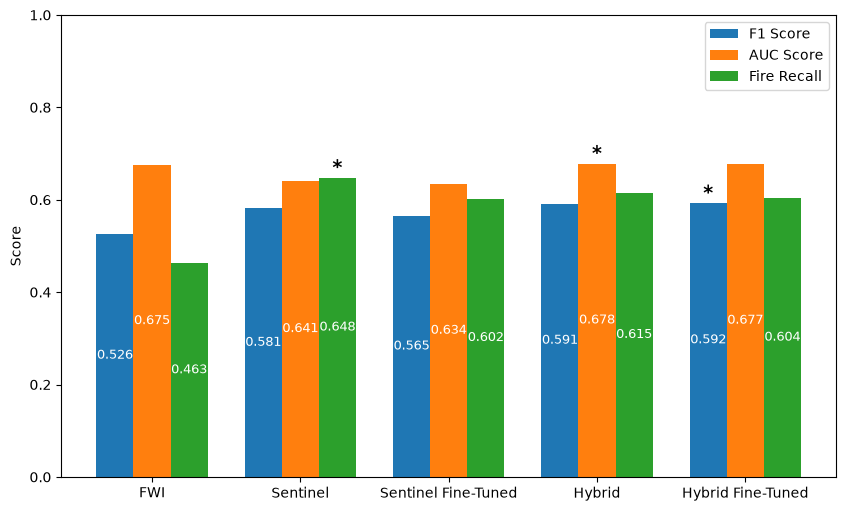

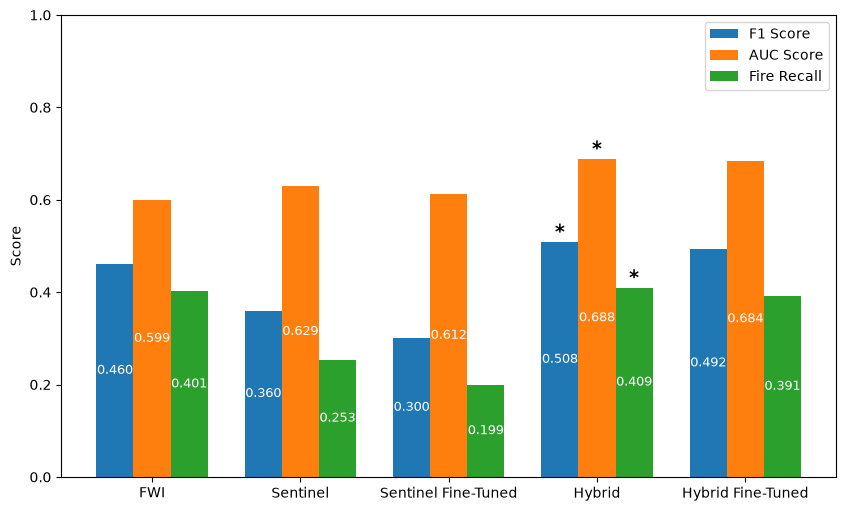

In [208]:
import numpy as np
from pathlib import Path

def plot_main_results(ax, 
                      df_for_plot: pd.DataFrame, 
                      plot_title:str, 
                      bar_width: float = 0.25,
                      show_legend: bool = True):

    # Plot parameters
    text_bar_font_size = 9
    text_bar_color = "white"

    # X axis labels
    labels = ["FWI",
              "Sentinel", 
              "Sentinel Fine-Tuned", 
              "Hybrid", 
              "Hybrid Fine-Tuned"]

    # Get the order of the models for plotting 
    x = np.arange(len(labels))

    # Extract the variables to plot 
    f1_scores = df_for_plot['f1'].values
    auc_scores = df_for_plot['roc_auc'].values
    fire_recall = df_for_plot['recall'].values


    # Draw the bars
    bars_f1 =  ax.bar(x - bar_width, f1_scores, width=bar_width, label='F1 Score')
    bars_auc = ax.bar(x, auc_scores, width=bar_width, label='AUC Score')
    bars_recall = ax.bar(x + bar_width, fire_recall, width=bar_width, label='Fire Recall')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    # Add value labels inside the bars
    # Add values inside each bar
    ax.bar_label(bars_f1,
                labels=[f"{v:.3f}" for v in f1_scores],
                label_type="center",
                fontsize=text_bar_font_size,
                color=text_bar_color)

    ax.bar_label(bars_auc,
                labels=[f"{v:.3f}" for v in auc_scores],
                label_type="center",
                fontsize=text_bar_font_size,
                color=text_bar_color)

    ax.bar_label(bars_recall,
                labels=[f"{v:.3f}" for v in fire_recall],
                label_type="center",
                fontsize=text_bar_font_size,
                color=text_bar_color)


    # Find the max value for each metric
    for bars, values in [(bars_f1, f1_scores),
                         (bars_auc, auc_scores),
                         (bars_recall, fire_recall)]:
        # Find the index of the max of the metric
        idx = np.argmax(values)
        # Find the corresponding bar object
        bar = bars[idx]
        # Add a star marker above the bar to indicate the max value
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                "*",
                ha="center",
                va="bottom",
                fontsize=14,
                fontweight="bold",
                color="black")

    # Set title and labels
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    if show_legend:
        ax.legend()

# Prepare path to save the plot
Path("outputs/plots").mkdir(parents=True, exist_ok=True)

# Create and save images
fig, ax = plt.subplots(figsize=(10, 6))
plot_main_results(ax, df_lr, "Logistic Regression")
fig.savefig("outputs/plots/logistic_regression_comparison.png",
            dpi=300,
            bbox_inches="tight")

fig, ax = plt.subplots(figsize=(10, 6))
plot_main_results(ax, df_rf, "Random Forest")
fig.savefig("outputs/plots/random_forest_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#### Performance by Metrics

In [151]:
df_test_results.columns

Index(['model', 'f1', 'precision', 'recall', 'roc_auc', 'confusion_matrix',
       'classification_report', 'precision_curve', 'recall_curve'],
      dtype='str')

In [176]:
df_by_f1 = (df_test_results[['model', 'f1', 'recall', 'precision', 'roc_auc']]
            .sort_values('f1', ascending=False)
            .rename(columns={"f1": "F1",
                             "recall": "Fire Recall",
                             "precision": "Fire Precision",
                             "roc_auc": "ROC AUC"})
            .round({"F1": 3,
                    "Fire Recall": 3,
                    "Fire Precision": 3,
                    "ROC AUC": 3})
            .reset_index(drop=True))
# Clean model names for presentation 
df_by_f1['model'] = (df_by_f1['model']
                     .str.replace("logistic_reg", "LR", regex=False)
                     .str.replace("random_forest", "RF", regex=False)
                     .str.replace("sentinel_default", "Sentinel", regex=False)
                     .str.replace("sentinel_fineTuned", "Sentinel FT", regex=False)
                     .str.replace("hybrid_default", "Hybrid", regex=False)
                     .str.replace("hybrid_fineTuned", "Hybrid FT", regex=False)
                     .str.replace("fwi", "FWI", regex=False)
                     .str.replace("_", " ", regex=False))
df_by_f1


,model,F1,Fire Recall,Fire Precision,ROC AUC
0,LR Hybrid FT,0.592,0.604,0.582,0.677
1,LR Hybrid,0.591,0.615,0.568,0.678
2,LR Sentinel,0.581,0.648,0.528,0.641
3,LR Sentinel FT,0.565,0.602,0.533,0.634
4,LR FWI,0.526,0.463,0.609,0.675
5,RF Hybrid,0.508,0.409,0.670,0.688
6,RF Hybrid FT,0.492,0.391,0.664,0.684
7,RF FWI,0.460,0.401,0.540,0.599
8,RF Sentinel,0.360,0.253,0.621,0.629
9,RF Sentinel FT,0.300,0.199,0.612,0.612


In [202]:
loaded_models.keys()
name_cleaner = {
    'logistic_reg_fwi': 'Logistic Regression - FWI',
    'logistic_reg_hybrid_default': 'Logistic Regression - Hybrid (Default)',
    'logistic_reg_hybrid_fineTuned': 'Logistic Regression - Hybrid (Fine-Tuned)',
    'logistic_reg_sentinel_default': 'Logistic Regression - Sentinel (Default)',
    'logistic_reg_sentinel_fineTuned': 'Logistic Regression - Sentinel (Fine-Tuned)',
    'random_forest_fwi': 'Random Forest - FWI',
    'random_forest_hybrid_default': 'Random Forest - Hybrid (Default)',
    'random_forest_hybrid_fineTuned': 'Random Forest - Hybrid (Fine-Tuned)',
    'random_forest_sentinel_default': 'Random Forest - Sentinel (Default)',
    'random_forest_sentinel_fineTuned': 'Random Forest - Sentinel (Fine-Tuned)'
}

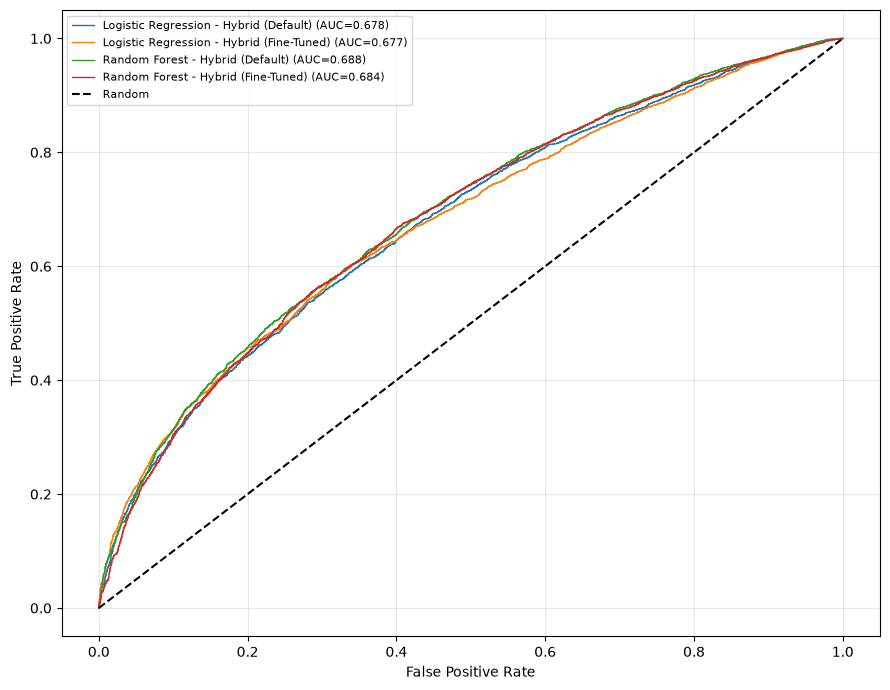

In [207]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

for m_name, search in loaded_models.items():

    if not m_name.__contains__('hybrid'):
        continue
    # Find the corresponding test dataset
    data_finder = re.sub(r"random_forest_|logistic_reg_", "", m_name)

    X_test = testing_predictor_data[data_finder]

    # Best tuned model
    model = search.best_estimator_

    # Predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Label name
    lbl_name = name_cleaner.get(m_name, m_name)

    plt.plot(fpr, tpr, lw=1,
             label=f"{lbl_name} (AUC={auc:.3f})")

# Random classifier
plt.plot([0,1],[0,1],'k--',label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plots/roc_curves_all_models.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [198]:
def compare_finetuned_models(df_in: pd.DataFrame, comp_metric: str) -> pd.DataFrame:

    df_transform = df_in[df_in['model'].str.contains('sentinel|hybrid')].copy()
    df_transform = df_transform[['model', comp_metric]]

    #Extract predictor type
    df_transform['predictor'] = df_transform['model'].apply(lambda x: "Sentinel" if "sentinel" in x else "Hybrid")
    # Extract CNN whether fine tuned or not
    df_transform['cnn_type'] = df_transform['model'].apply(lambda x: "Fine-Tuned" if "fineTuned" in x else "Default")
    # Extract ML model
    df_transform['ml_model'] = df_transform['model'].apply(lambda x: "Random Forest" if "random_forest" in x else "Logistic Regression")
    # Comvine model name
    df_transform['model_name'] = df_transform['ml_model'] + " - " + df_transform['predictor']
    # Comparison df
    comparison = (df_transform.pivot(index='model_name', columns='cnn_type', values=comp_metric).reset_index().round(3))
    comparison['Improvement'] = comparison['Fine-Tuned'] - comparison['Default']
    return comparison.sort_values('Improvement', ascending=False).reset_index(drop=True)

compare_finetuned_models(df_test_results, 'f1')
compare_finetuned_models(df_test_results, 'recall')


cnn_type,model_name,Default,Fine-Tuned,Improvement
0,Logistic Regression - Hybrid,0.615,0.604,-0.011
1,Random Forest - Hybrid,0.409,0.391,-0.018
2,Logistic Regression - Sentinel,0.648,0.602,-0.046
3,Random Forest - Sentinel,0.253,0.199,-0.054
